# Laboratorio di Simulazione Numerica — Esercizio 04

In questo esercizio si modifica il simulatore di Dinamica Molecolare fornito per studiare un sistema rarefatto di particelle interagenti tramite potenziale di Lennard-Jones, espresso in unità ridotte.

Le modifiche principali riguardano:

1. la misura della distribuzione dei moduli delle velocità;
2. la preparazione di uno stato iniziale lontano dall'equilibrio e il rilassamento della distribuzione delle velocità verso Maxwell-Boltzmann;
3. lo studio della reversibilità temporale della dinamica Verlet.

Il notebook legge direttamente gli output prodotti dal codice C++ nella cartella `Ex_04/OUTPUT`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("Ex_04")
OUTPUT = BASE / "OUTPUT"

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "font.size": 12
})

## Modello e metodo numerico

Il codice simula un sistema classico di $N$ particelle interagenti tramite potenziale di Lennard-Jones. Le grandezze sono espresse in unità ridotte, cioè usando come unità naturali del problema i parametri caratteristici del potenziale: $\sigma$ per le lunghezze, $\epsilon$ per le energie e la massa $m$ delle particelle. In queste unità il potenziale può essere scritto come

$$
V(r)=4\left[\left(\frac{1}{r}\right)^{12}-\left(\frac{1}{r}\right)^6\right].
$$

La dinamica molecolare viene integrata in ensemble microcanonico NVE: numero di particelle, volume ed energia totale sono fissati. Le equazioni del moto sono propagate con l'algoritmo di Verlet nella forma position-Verlet,

$$
\vec r(t+\Delta t)=2\vec r(t)-\vec r(t-\Delta t)+\vec a(t)\Delta t^2,
$$

dove l'accelerazione è calcolata dalle forze di Lennard-Jones. Questa forma dell'algoritmo usa due configurazioni consecutive, $\vec r(t)$ e $\vec r(t-\Delta t)$, e non richiede le velocità come variabili dinamiche indipendenti.

Per ridurre gli effetti di bordo si usano condizioni periodiche al contorno. Quando una particella esce da un lato della scatola, rientra dal lato opposto; le distanze tra particelle sono calcolate usando la convenzione dell'immagine minima.

## Struttura del progetto

Per evitare di duplicare il codice e di sovrascrivere i risultati, è stata usata una singola cartella `SOURCE/` e una cartella separata di input/output per ogni simulazione:

```text
Ex_04/
  SOURCE/
  INPUT/
    equilibrium/
    delta_initial/
    velocity_relaxation/
    forward_5k/
    reverse_5k/
    forward_50k/
    reverse_50k/
  OUTPUT/
    equilibrium/
    delta_initial/
    velocity_relaxation/
    forward_5k/
    reverse_5k/
    forward_50k/
    reverse_50k/
```

Il simulatore viene lanciato passando il nome della run da terminale:

```bash
./simulator.exe equilibrium
./simulator.exe velocity_relaxation
./simulator.exe forward_5k
```

In questo modo lo stesso eseguibile legge da `INPUT/<run>` e scrive in `OUTPUT/<run>`.

Nel `main` il nome della run viene letto da riga di comando:

```cpp
int main (int argc, char *argv[]){

  if(argc < 2){
    cerr << "Usage: ./simulator.exe RUN_NAME" << endl;
    cerr << "Example: ./simulator.exe equilibrium" << endl;
    return 1;
  }

  string run_name = argv[1];

  System SYS(run_name);
  SYS.initialize();
  SYS.initialize_properties();
  SYS.block_reset(0);

  for(int i=0; i < SYS.get_nbl(); i++){
    for(int j=0; j < SYS.get_nsteps(); j++){
      SYS.step();
      SYS.measure();
    }
    SYS.averages(i+1);
    SYS.block_reset(i+1);
  }

  SYS.finalize();

  return 0;
}
```

È stata rimossa la scrittura di una configurazione `.xyz` a ogni step, perché avrebbe prodotto migliaia di file non necessari. Rimangono invece i file finali `config.xyz` e `conf-1.xyz`, usati per il restart e per l'inversione temporale.

Nel costruttore di `System` sono stati introdotti percorsi dipendenti dalla run:

```cpp
System :: System(string run_name){
  _run_name = run_name;
  _input_dir = "../INPUT/" + run_name;
  _output_dir = "../OUTPUT/" + run_name;
}

string System :: input_path(string filename){
  return _input_dir + "/" + filename;
}

string System :: output_path(string filename){
  return _output_dir + "/" + filename;
}
```

Tutti i file vengono poi aperti usando `input_path(...)` e `output_path(...)`. Questo permette di tenere separati gli output delle diverse simulazioni.

In [2]:
def read_md_observable(path):
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["BLOCK", "ACTUAL", "AVE", "ERROR"]
    )

def read_pofv_blocks(path, has_error=False):
    # La funzione restituisce una lista di DataFrame, uno per ogni blocco/istogramma salvato.
    blocks = []
    current = []

    with open(path) as f:
        for line in f:
            line = line.strip()

            # Una riga vuota o una riga di commento segnala la fine dell'istogramma corrente.
            if not line or line.startswith("#"):
                if current:
                    columns = ["v", "p", "err"] if has_error else ["v", "p"]
                    blocks.append(pd.DataFrame(current, columns=columns))
                    current = []
                continue

            current.append([float(x) for x in line.split()])

    return blocks

def maxwell_boltzmann(v, T):

    return 4*np.pi*v**2 / (2*np.pi*T)**1.5 * np.exp(-v**2/(2*T))

def final_temperature(run, last_blocks=10):

    temp = read_md_observable(OUTPUT / run / "temperature.dat")
    return temp["ACTUAL"].tail(last_blocks).mean()

def check_histogram_area(block):

    dv = block["v"].iloc[1] - block["v"].iloc[0]
    return (block["p"] * dv).sum()

## Esercizio 04.1 — Distribuzione delle velocità

La distribuzione teorica di Maxwell-Boltzmann per il modulo della velocità in tre dimensioni è

$$
p(v,T)=
\frac{4\pi v^2}{(2\pi T)^{3/2}}
e^{-\frac{v^2}{2T}}.
$$

La grandezza da confrontare con questa curva è il modulo

$$
v_i = |\vec v_i| = \sqrt{v_{x,i}^2+v_{y,i}^2+v_{z,i}^2},
$$

La nuova proprietà viene attivata in `properties.dat` con una riga del tipo

```text
POFV 30 6.0
```

dove `30` è il numero di bin e `6.0` è il valore massimo di velocità considerato. Nel codice C++ si legge:

```cpp
input >> _n_bins_v >> _v_max;

_nprop += _n_bins_v;
_bin_size_v = _v_max / double(_n_bins_v);
_measure_pofv = true;
_index_pofv = index_property;
index_property += _n_bins_v;
```

Durante la misura, ogni particella contribuisce al bin corrispondente al suo modulo della velocità:

```cpp
if (_measure_pofv){
  for(int i=0; i<_npart; i++){
    vec v = _particle(i).getvelocity();
    double v_mod = sqrt(dot(v,v));
    int bin_v = int(v_mod / _bin_size_v);

    if(bin_v >= 0 && bin_v < _n_bins_v){
      _measurement(_index_pofv + bin_v) +=
        1.0 / (double(_npart) * _bin_size_v);
    }
  }
}
```

La normalizzazione è scelta in modo che l'istogramma sia una densità di probabilità:

$$
\sum_j p(v_j)\Delta v \simeq 1.
$$

Per `pofv.dat` viene salvata la media progressiva di ciascun bin con la relativa incertezza da data blocking, in particolare sono stati generati 50 blocchi da 1000 passi ciascuno. Questo è adatto per il confronto finale con Maxwell-Boltzmann.

Area of final histogram = 1.00000009
Effective temperature = 0.555


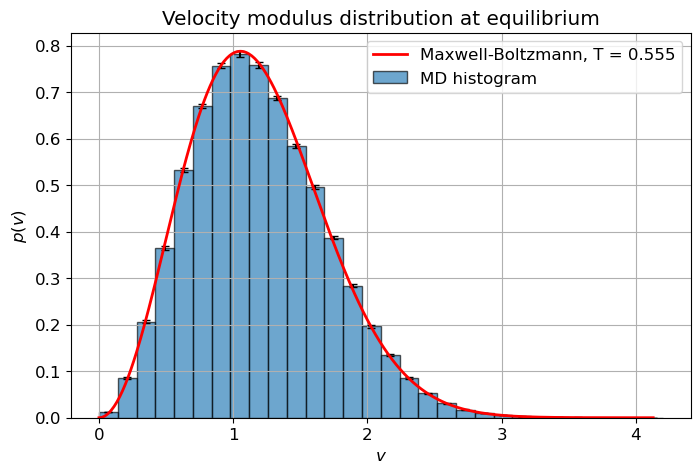

In [3]:
run = "equilibrium"

pofv_blocks = read_pofv_blocks(OUTPUT / run / "pofv.dat", has_error=True)

# Prendo l'ultimo istogramma salvato, cioè quello che corrisponde alla stima progressiva finale.
last = pofv_blocks[-1]

dv = last["v"].iloc[1] - last["v"].iloc[0]
area = check_histogram_area(last)

T_eff = final_temperature(run, last_blocks=5)

# Curva teorica di Maxwell-Boltzmann usando la temperatura effettiva.
v_grid = np.linspace(0, last["v"].max(), 400)
p_mb = maxwell_boltzmann(v_grid, T_eff)

print(f"Area of final histogram = {area:.8f}")
print(f"Effective temperature = {T_eff:.3f}")

plt.bar(
    last["v"],
    last["p"],
    width=dv,
    align="center",
    yerr=last["err"],
    capsize=3,
    alpha=0.65,
    edgecolor="black",
    label="MD histogram"
)

plt.plot(
    v_grid,
    p_mb,
    linewidth=2,
    label=f"Maxwell-Boltzmann, T = {T_eff:.3f}",
    color="red"
)

plt.xlabel("$v$")
plt.ylabel("$p(v)$")
plt.title("Velocity modulus distribution at equilibrium")
plt.legend()
plt.show()

L'area dell'istogramma è circa unitaria, quindi la normalizzazione è corretta. Il confronto va fatto usando la temperatura effettiva misurata dalla simulazione, non necessariamente quella nominale scritta nell'input. La simulazione MD è infatti in ensemble NVE: l'energia totale è la grandezza conservata, mentre la temperatura può oscillare.

## Esercizio 04.2 — Rilassamento verso Maxwell-Boltzmann

La seconda parte richiede di partire da uno stato molto lontano dall'equilibrio e osservare il rilassamento della distribuzione delle velocità.

Lo stato iniziale è costruito con:

```text
CONFIG_MODE       FCC_HALF_BOX
INIT_VELOCITIES   DELTA_AXES
```

La configurazione fcc viene compressa in metà scatola in ciascuna direzione. Se la densità globale è

$$
\rho^* = 0.05,
$$

il volume inizialmente occupato è $L^3/8$, quindi la densità locale iniziale è circa

$$
\rho^*_{\mathrm{local}} \simeq 8\rho^* = 0.40.
$$

La modalità `CONFIG_MODE` è gestita in `read_configuration()`:

```cpp
if(_config_mode == "FCC_HALF_BOX"){
  config_file = "CONFIG/config.fcc";
  config_scale = 0.5;
}

_particle(i).setposition(0, this->pbc(_side(0) * config_scale * x, 0));
_particle(i).setposition(1, this->pbc(_side(1) * config_scale * y, 1));
_particle(i).setposition(2, this->pbc(_side(2) * config_scale * z, 2));
```

La modalità `INIT_VELOCITIES DELTA_AXES` assegna a tutte le particelle lo stesso modulo della velocità:

```cpp
double v0 = sqrt(3.0 * _temp);

for (int i=0; i<_npart; i++){
  int direction = i % 6;

  if(direction == 0)      vx(i) =  v0;
  else if(direction == 1) vx(i) = -v0;
  else if(direction == 2) vy(i) =  v0;
  else if(direction == 3) vy(i) = -v0;
  else if(direction == 4) vz(i) =  v0;
  else if(direction == 5) vz(i) = -v0;
}
```

La scelta

$$
v_0=\sqrt{3T^*}
$$

segue da

$$
T^* = \frac{\langle v^2\rangle}{3}.
$$

Per $T^*=2.0$ si ha $v_0=\sqrt{6}\simeq 2.45$.

Per controllare la condizione iniziale è stata usata la run `delta_initial`, con un numero minimo di step. Il risultato atteso è un unico picco nel bin vicino a $v=\sqrt{6}$.

Per seguire il rilassamento temporale, oltre a `pofv.dat` è stato aggiunto un secondo file:

```text
pofv_blocks.dat
```

La differenza è importante:

- `pofv.dat` contiene la media progressiva dei bin con errore, utile per una stima finale;
- `pofv_blocks.dat` contiene invece l'istogramma del singolo blocco, utile per vedere l'evoluzione temporale.

Nel codice, dentro `averages()`, si scrive anche:

```cpp
ofstream coutfb;
coutfb.open(output_path("pofv_blocks.dat"),ios::app);

for(int i=0; i<_n_bins_v; i++){
  int index = _index_pofv + i;

  double v_center = (double(i) + 0.5) * _bin_size_v;
  average = _average(index);

  coutfb << v_center << " "
         << average
         << endl;
}

coutfb << endl;
coutfb.close();
```

La run dedicata a questa analisi è `velocity_relaxation`, con 30 blocchi da 1000 step.

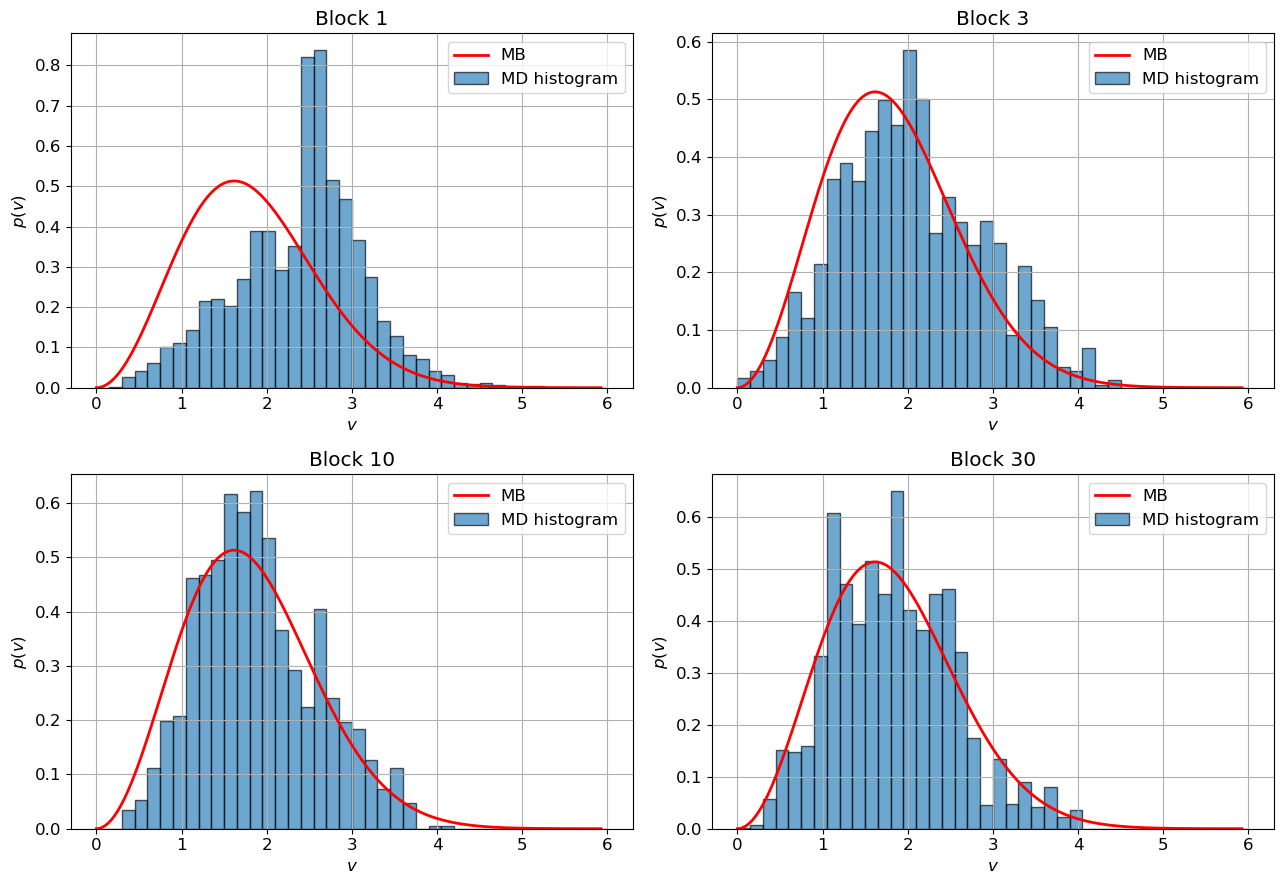

In [4]:
run = "velocity_relaxation"

blocks = read_pofv_blocks(OUTPUT / run / "pofv_blocks.dat", has_error=False)

temp = read_md_observable(OUTPUT / run / "temperature.dat")

selected = [0, 2, 9, 29]

T_final = final_temperature(run, last_blocks=5)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, idx in zip(axes, selected):
    # Estraggo l'istogramma del blocco scelto.
    block = blocks[idx]

    block_number = idx + 1

    dv = block["v"].iloc[1] - block["v"].iloc[0]

    # Costruisco la curva teorica di Maxwell-Boltzmann
    v_grid = np.linspace(0, block["v"].max(), 400)
    p_mb = maxwell_boltzmann(v_grid, T_final)

    # Disegno l'istogramma del blocco selezionato.
    ax.bar(
        block["v"],
        block["p"],
        width=dv,
        align="center",
        alpha=0.65,
        edgecolor="black",
        label="MD histogram"
    )

    # Sovrappongo la curva teorica di Maxwell-Boltzmann.
    ax.plot(
        v_grid,
        p_mb,
        linewidth=2,
        label="MB",
        color="red"
    )

    ax.set_title(f"Block {block_number}")
    ax.set_xlabel("$v$")
    ax.set_ylabel("$p(v)$")
    ax.legend()

plt.tight_layout()
plt.show()

In tutti i pannelli la curva teorica è la stessa Maxwell-Boltzmann, calcolata usando la temperatura media degli ultimi blocchi della simulazione. In questo modo il confronto mostra direttamente il rilassamento della distribuzione iniziale verso la distribuzione di equilibrio finale.

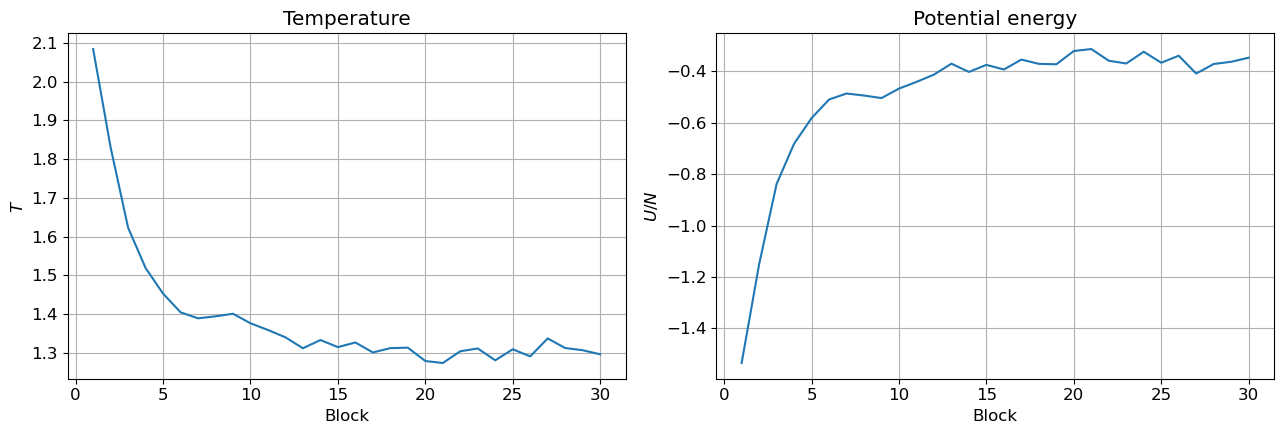

In [5]:
temp = read_md_observable(OUTPUT / "velocity_relaxation" / "temperature.dat")
pot = read_md_observable(OUTPUT / "velocity_relaxation" / "potential_energy.dat")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(temp["BLOCK"], temp["ACTUAL"])
axes[0].set_xlabel("Block")
axes[0].set_ylabel("$T$")
axes[0].set_title("Temperature")

axes[1].plot(pot["BLOCK"], pot["ACTUAL"])
axes[1].set_xlabel("Block")
axes[1].set_ylabel("$U/N$")
axes[1].set_title("Potential energy")

plt.tight_layout()
plt.show()

La distribuzione iniziale è molto lontana da Maxwell-Boltzmann: i moduli delle velocità sono inizialmente concentrati in un intervallo stretto. Dopo alcuni blocchi la distribuzione si allarga e cambia forma; alla fine della simulazione è compatibile con una distribuzione Maxwell-Boltzmann alla temperatura effettiva finale.

Occorre sottolineare che gli istogrammi mostrati sono medie di blocco, non medie progressive. Per questo motivo rimane un certo rumore statistico nei singoli pannelli, anche quando la forma complessiva è già vicina alla curva teorica.

La temperatura non resta necessariamente uguale al valore nominale iniziale, perché la simulazione è NVE: durante l'espansione del grumo iniziale energia cinetica e potenziale si redistribuiscono.

## Esercizio 04.3 — Inversione temporale

Il codice usa l'algoritmo position-Verlet. Lo stato dinamico non è rappresentato solo da posizione e velocità, ma dalla coppia di configurazioni consecutive

$$
\{\vec r(t), \vec r(t-\Delta t)\}.
$$

Per invertire la traiettoria, quindi, non è necessario invertire esplicitamente le velocità: si scambiano le due configurazioni finali della run forward.

Se la run diretta finisce con

```text
OUTPUT/forward_5k/CONFIG/config.xyz   -> r_N
OUTPUT/forward_5k/CONFIG/conf-1.xyz   -> r_{N-1}
```

la run inversa viene preparata con

```bash
cp OUTPUT/forward_5k/CONFIG/conf-1.xyz INPUT/reverse_5k/CONFIG/config.xyz
cp OUTPUT/forward_5k/CONFIG/config.xyz INPUT/reverse_5k/CONFIG/conf-1.xyz
```

Così il normale meccanismo di `RESTART = 1` del codice è sufficiente: `read_configuration()` legge la posizione corrente, mentre `initialize_velocities()` legge la configurazione precedente.

Nel ramo restart di `initialize_velocities()`:

```cpp
if(_restart){
  ifstream cinf;
  cinf.open(input_path("CONFIG/conf-1.xyz"));

  if(cinf.is_open()){
    string comment;
    string particle;
    int ncoord;
    cinf >> ncoord;
    cinf >> comment;

    for(int i=0; i<_npart; i++){
      cinf >> particle >> xold >> yold >> zold;
      _particle(i).setpositold(0, this->pbc(_side(0)*xold, 0));
      _particle(i).setpositold(1, this->pbc(_side(1)*yold, 1));
      _particle(i).setpositold(2, this->pbc(_side(2)*zold, 2));
    }
  }
}
```

Questo rende naturale l'inversione temporale con lo scambio dei file `config.xyz` e `conf-1.xyz`.

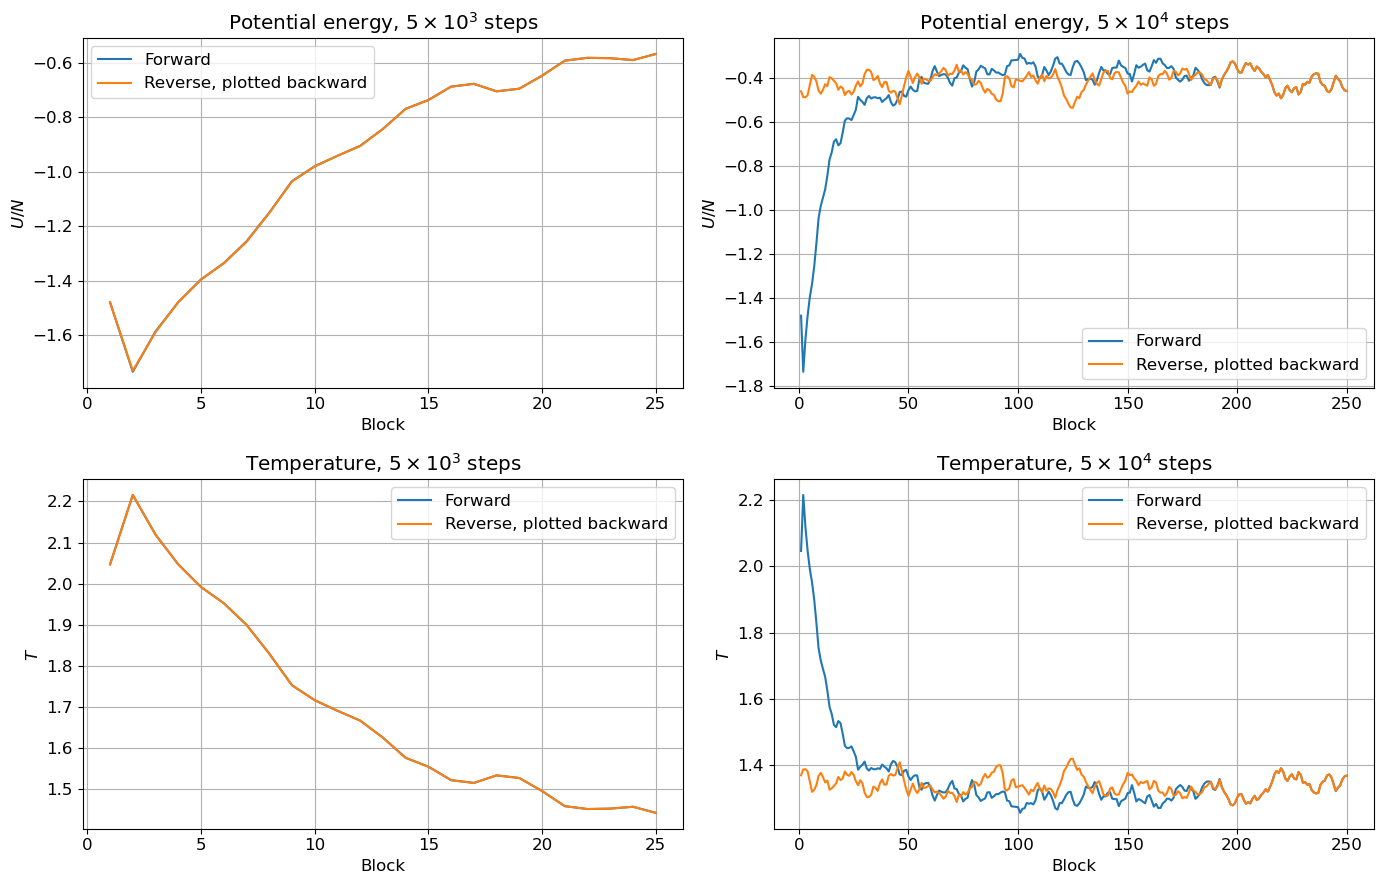

In [6]:
def load_case(run):
    pot = read_md_observable(OUTPUT / run / "potential_energy.dat")
    temp = read_md_observable(OUTPUT / run / "temperature.dat")
    return pot, temp

def reversed_actual(df):
    out = pd.DataFrame()
    out["BLOCK"] = np.arange(1, len(df)+1)
    out["ACTUAL"] = df["ACTUAL"].iloc[::-1].values
    return out
fwd_pot_5k, fwd_temp_5k = load_case("forward_5k")
rev_pot_5k, rev_temp_5k = load_case("reverse_5k")

fwd_pot_50k, fwd_temp_50k = load_case("forward_50k")
rev_pot_50k, rev_temp_50k = load_case("reverse_50k")

rev_pot_5k_rt = reversed_actual(rev_pot_5k)
rev_temp_5k_rt = reversed_actual(rev_temp_5k)
rev_pot_50k_rt = reversed_actual(rev_pot_50k)
rev_temp_50k_rt = reversed_actual(rev_temp_50k)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].plot(fwd_pot_5k["BLOCK"], fwd_pot_5k["ACTUAL"], label="Forward")
axes[0,0].plot(rev_pot_5k_rt["BLOCK"], rev_pot_5k_rt["ACTUAL"], label="Reverse, plotted backward")
axes[0,0].set_title(r"Potential energy, $5\times 10^3$ steps")
axes[0,0].set_xlabel("Block")
axes[0,0].set_ylabel("$U/N$")
axes[0,0].legend()

axes[0,1].plot(fwd_pot_50k["BLOCK"], fwd_pot_50k["ACTUAL"], label="Forward")
axes[0,1].plot(rev_pot_50k_rt["BLOCK"], rev_pot_50k_rt["ACTUAL"], label="Reverse, plotted backward")
axes[0,1].set_title(r"Potential energy, $5\times 10^4$ steps")
axes[0,1].set_xlabel("Block")
axes[0,1].set_ylabel("$U/N$")
axes[0,1].legend()

axes[1,0].plot(fwd_temp_5k["BLOCK"], fwd_temp_5k["ACTUAL"], label="Forward")
axes[1,0].plot(rev_temp_5k_rt["BLOCK"], rev_temp_5k_rt["ACTUAL"], label="Reverse, plotted backward")
axes[1,0].set_title(r"Temperature, $5\times 10^3$ steps")
axes[1,0].set_xlabel("Block")
axes[1,0].set_ylabel("$T$")
axes[1,0].legend()

axes[1,1].plot(fwd_temp_50k["BLOCK"], fwd_temp_50k["ACTUAL"], label="Forward")
axes[1,1].plot(rev_temp_50k_rt["BLOCK"], rev_temp_50k_rt["ACTUAL"], label="Reverse, plotted backward")
axes[1,1].set_title(r"Temperature, $5\times 10^4$ steps")
axes[1,1].set_xlabel("Block")
axes[1,1].set_ylabel("$T$")
axes[1,1].legend()

plt.tight_layout()
plt.show()

Per la traiettoria breve, la dinamica inversa segue molto bene la traiettoria diretta letta al contrario. Questo mostra che lo scambio delle configurazioni è coerente con la struttura position-Verlet del codice.

Per la traiettoria lunga, invece, la ricostruzione dello stato iniziale fallisce in modo macroscopico. Il sistema non ritorna alla configurazione iniziale ordinata e localizzata, ma rimane in uno stato più simile a un gas rilassato.

È importante distinguere due aspetti diversi. L'algoritmo di Verlet è certamente un'approssimazione della dinamica continua reale, perché usa un passo temporale finito $\Delta t$. Tuttavia questo non è il motivo per cui la traiettoria numerica non torna perfettamente indietro. Una volta fissato $\Delta t$, Verlet definisce una dinamica discreta che è simmetrica per inversione temporale: in aritmetica esatta, scambiando le due configurazioni consecutive finali, la traiettoria discreta verrebbe ripercorsa all'indietro.

Il problema nasce dal fatto che il calcolo numerico non avviene in aritmetica esatta. Le coordinate vengono salvate con precisione finita, le operazioni floating point introducono arrotondamenti e le condizioni periodiche possono amplificare piccole differenze nella ricostruzione dello stato microscopico. In un sistema caotico a molti corpi, queste differenze inizialmente piccolissime crescono rapidamente. Dopo una traiettoria breve l'errore resta abbastanza piccolo e la ricostruzione è ancora visibile; dopo una traiettoria lunga, invece, gli errori numerici vengono amplificati al punto da impedire il ritorno alla configurazione iniziale a bassa entropia.

Quindi il risultato non contraddice la reversibilità microscopica delle equazioni del moto. Mostra piuttosto che la reversibilità richiede una conoscenza estremamente precisa dello stato microscopico. La configurazione iniziale ordinata occupa una regione molto speciale dello spazio delle fasi: basta una deviazione numerica minuscola perché, dopo un tempo sufficientemente lungo, la traiettoria inversa non riesca più a raggiungerla.

## Guida rapida di esecuzione

Da `Ex_04/SOURCE/`:

```bash
make clean
make
```

Per produrre i dati principali:

```bash
./simulator.exe equilibrium
./simulator.exe delta_initial
./simulator.exe velocity_relaxation
./simulator.exe forward_5k
```

Poi preparare la reverse breve:

```bash
cp ../OUTPUT/forward_5k/CONFIG/conf-1.xyz ../INPUT/reverse_5k/CONFIG/config.xyz
cp ../OUTPUT/forward_5k/CONFIG/config.xyz ../INPUT/reverse_5k/CONFIG/conf-1.xyz
./simulator.exe reverse_5k
```

Per la traiettoria lunga:

```bash
./simulator.exe forward_50k
cp ../OUTPUT/forward_50k/CONFIG/conf-1.xyz ../INPUT/reverse_50k/CONFIG/config.xyz
cp ../OUTPUT/forward_50k/CONFIG/config.xyz ../INPUT/reverse_50k/CONFIG/conf-1.xyz
./simulator.exe reverse_50k
```